# Torch vs TensorFlow PromoterAI Benchmark Scores

This notebook compares ensembled variant scores from the PyTorch benchmark runner against scores from the official TensorFlow/Keras PromoterAI SavedModels across the public paper benchmark datasets.

Run the torch and TensorFlow benchmark scripts first so each dataset has a scored TSV or TSV.GZ in `TORCH_RESULTS_DIR` and `TF_RESULTS_DIR`.

In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

## Inputs

The file finder supports both layouts used by the benchmark scripts:

- all outputs in one directory, e.g. `examples/data/GTEx_outlier.scores.tsv.gz`
- per-dataset directories, e.g. `results/benchmark/GTEx_outlier/GTEx_outlier.scores.tsv`

In [9]:
DATASETS = [
    "CAGI5_saturation",
    "GEL_RNA",
    "GTEx_eQTL",
    "GTEx_outlier",
    "MPRA_eQTL",
    "MPRA_saturation",
    "UKBB_proteome",
]

TORCH_RESULTS_DIR = Path("../data")
TF_RESULTS_DIR = Path("../data")

OUT_DIR = Path("../img/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SCORE_COL = "score"
VARIANT_COLS = ["chrom", "pos", "ref", "alt", "strand", "gene", "consequence"]

In [3]:
def find_score_file(root: Path, dataset: str, tensorflow: bool = False) -> Path:
    suffixes = (
        [".tensorflow.scores.tsv", ".tensorflow.scores.tsv.gz"]
        if tensorflow
        else [".scores.tsv", ".scores.tsv.gz"]
    )
    candidates = []
    for suffix in suffixes:
        candidates.extend([root / f"{dataset}{suffix}", root / dataset / f"{dataset}{suffix}"])
        candidates.extend(sorted(root.glob(f"**/{dataset}{suffix}")))
    seen = set()
    for path in candidates:
        if path in seen:
            continue
        seen.add(path)
        if path.exists():
            return path
    label = "TensorFlow" if tensorflow else "torch"
    raise FileNotFoundError(f"Could not find {label} scored TSV for {dataset} under {root}")


def load_paired_scores(dataset: str) -> pd.DataFrame:
    torch_path = find_score_file(TORCH_RESULTS_DIR, dataset, tensorflow=False)
    tf_path = find_score_file(TF_RESULTS_DIR, dataset, tensorflow=True)
    torch_df = pd.read_csv(torch_path, sep="\t").reset_index(drop=True)
    tf_df = pd.read_csv(tf_path, sep="\t").reset_index(drop=True)

    if len(torch_df) != len(tf_df):
        raise ValueError(
            f"{dataset}: torch has {len(torch_df)} rows but TensorFlow has {len(tf_df)} rows"
        )
    for col in (SCORE_COL,):
        if col not in torch_df.columns:
            raise KeyError(f"{torch_path} is missing {col!r}")
        if col not in tf_df.columns:
            raise KeyError(f"{tf_path} is missing {col!r}")

    shared_variant_cols = [
        col for col in VARIANT_COLS if col in torch_df.columns and col in tf_df.columns
    ]
    if shared_variant_cols:
        mismatched = (
            torch_df[shared_variant_cols].astype(str).to_numpy()
            != tf_df[shared_variant_cols].astype(str).to_numpy()
        ).any(axis=1)
        if mismatched.any():
            n_bad = int(mismatched.sum())
            raise ValueError(f"{dataset}: {n_bad} row-aligned variants do not match")

    paired = torch_df[shared_variant_cols].copy()
    paired.insert(0, "dataset", dataset)
    paired["torch_score"] = torch_df[SCORE_COL].astype(float)
    paired["tensorflow_score"] = tf_df[SCORE_COL].astype(float)
    paired["abs_error"] = (paired["torch_score"] - paired["tensorflow_score"]).abs()
    return paired

In [4]:
paired_by_dataset = {dataset: load_paired_scores(dataset) for dataset in DATASETS}
all_scores = pd.concat(paired_by_dataset.values(), ignore_index=True)
all_scores.head()

,dataset,chrom,pos,ref,alt,strand,gene,consequence,torch_score,tensorflow_score,abs_error
0,CAGI5_saturation,chr1,155301395,T,A,-1,PKLR,over,-0.034376,-0.034376,0.0
1,CAGI5_saturation,chr1,155301397,C,A,-1,PKLR,under,-0.003299,-0.003299,0.0
2,CAGI5_saturation,chr1,155301398,T,A,-1,PKLR,over,-0.030438,-0.030438,0.0
3,CAGI5_saturation,chr1,155301405,G,T,-1,PKLR,none,0.078088,0.078088,0.0
4,CAGI5_saturation,chr1,155301406,T,A,-1,PKLR,none,-0.020496,-0.020496,0.0


In [5]:
def agreement_stats(df: pd.DataFrame) -> pd.Series:
    x = df["torch_score"].to_numpy(dtype=float)
    y = df["tensorflow_score"].to_numpy(dtype=float)
    corr = np.corrcoef(x, y)[0, 1] if len(df) > 1 else math.nan
    return pd.Series(
        {
            "n": len(df),
            "pearson_r": corr,
            "mae": np.mean(np.abs(x - y)),
            "max_abs_error": np.max(np.abs(x - y)),
        }
    )


stats = (
    all_scores.groupby("dataset", sort=False)
    .apply(agreement_stats)
    .reset_index()
)
combined = agreement_stats(all_scores).to_frame().T
combined.insert(0, "dataset", "all")
stats = pd.concat([stats, combined], ignore_index=True)
stats

/var/folders/z5/ckjfz_p9113dbbtqxyhlmbxw0000gn/T/ipykernel_83413/954342630.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(agreement_stats)


,dataset,n,pearson_r,mae,max_abs_error
0,CAGI5_saturation,6570.0,1.0,3.228160e-08,0.000050
1,GEL_RNA,1157.0,1.0,1.306866e-07,0.000050
2,GTEx_eQTL,802.0,1.0,1.714377e-07,0.000050
3,GTEx_outlier,749.0,1.0,1.025375e-07,0.000043
4,MPRA_eQTL,686.0,1.0,1.426132e-07,0.000050
5,MPRA_saturation,5029.0,1.0,7.514342e-08,0.000050
6,UKBB_proteome,1011.0,1.0,1.361942e-07,0.000050
7,all,16004.0,1.0,7.441948e-08,0.000050


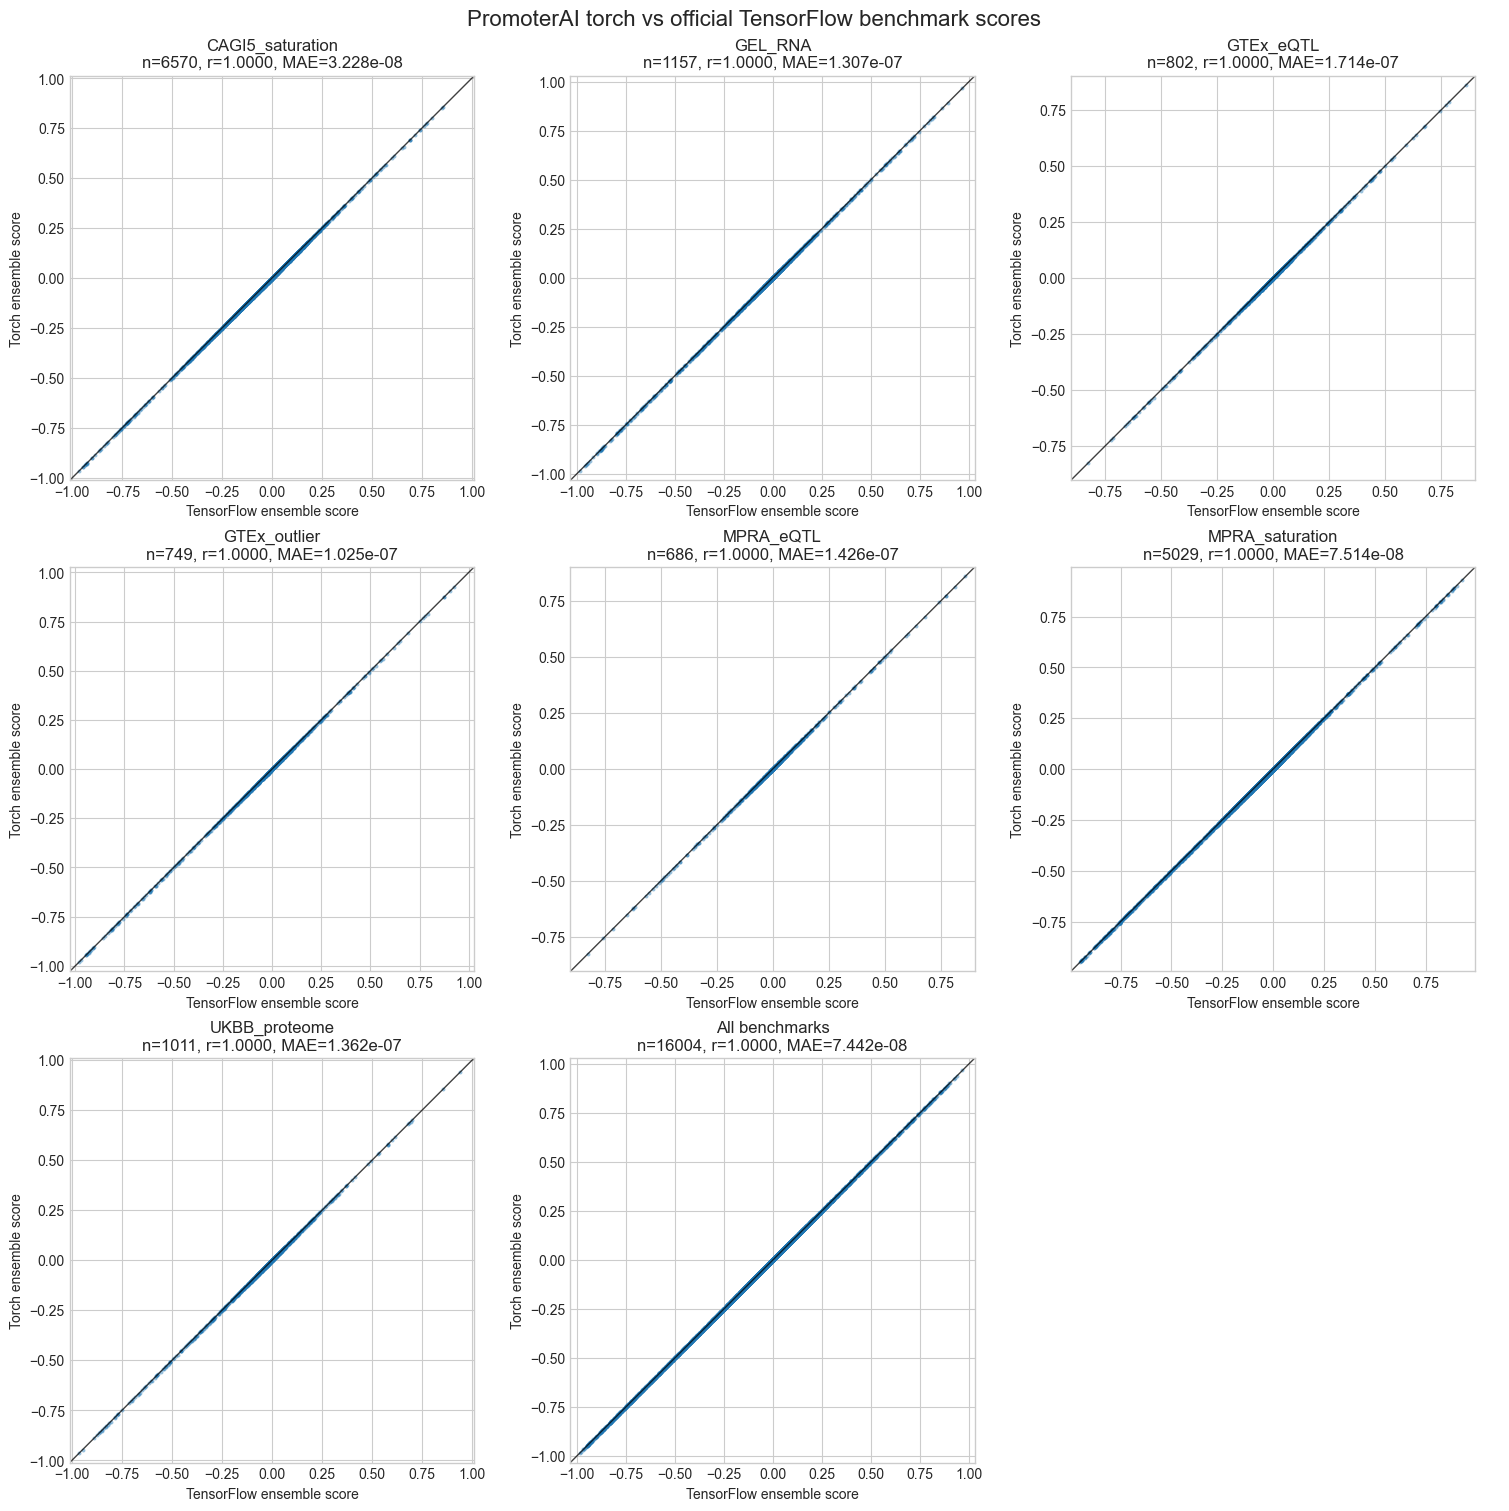

In [ ]:
def scatter_panel(ax, df: pd.DataFrame, title: str) -> None:
    x = df["tensorflow_score"].to_numpy(dtype=float)
    y = df["torch_score"].to_numpy(dtype=float)
    limit = max(0.05, float(np.nanmax(np.abs(np.concatenate([x, y])))))
    pad = limit * 0.05
    lims = (-limit - pad, limit + pad)
    ax.scatter(x, y, s=8, alpha=0.45, linewidths=0)
    ax.plot(lims, lims, color="black", linewidth=1, alpha=0.75)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal", adjustable="box")
    row = agreement_stats(df)
    ax.set_title(
        f"{title}\n"
        f"n={int(row['n'])}, r={row['pearson_r']:.4f}, MAE={row['mae']:.4g}"
    )
    ax.set_xlabel("TensorFlow ensemble score")
    ax.set_ylabel("Torch ensemble score")


ncols = 3
nrows = math.ceil((len(DATASETS) + 1) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), constrained_layout=True)
axes = np.asarray(axes).reshape(-1)

for ax, dataset in zip(axes, DATASETS):
    scatter_panel(ax, paired_by_dataset[dataset], dataset)

scatter_panel(axes[len(DATASETS)], all_scores, "All benchmarks")
for ax in axes[len(DATASETS) + 1 :]:
    ax.axis("off")

fig.suptitle("PromoterAI torch vs official TensorFlow benchmark scores", fontsize=16)
fig.savefig(OUT_DIR / "paper_benchmark_concordance.png", dpi=200)
plt.show()

In [ ]:
# Optional: save the paired score table and agreement summary for downstream checks.
all_scores.to_csv(TORCH_RESULTS_DIR / "torch_vs_tensorflow_paired_scores.tsv.tz", sep="\t", index=False)
stats.to_csv(TORCH_RESULTS_DIR / "torch_vs_tensorflow_score_agreement.tsv.gz", sep="\t", index=False)
OUT_DIR

PosixPath('../img')